In [1]:
import os
import torch
import kagglehub
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from transformers import ViTImageProcessor, ViTForImageClassification
from sklearn.metrics import classification_report, confusion_matrix

# 1. SETUP & DATA LOADING
base_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

model_name = 'google/vit-base-patch16-224'
processor = ViTImageProcessor.from_pretrained(model_name)

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Use smaller subsets if compute is limited
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. MODEL INITIALIZATION
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

# 3. TRAINING LOOP (Phase 1: Build)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5) # Lower LR for ViT
criterion = torch.nn.CrossEntropyLoss()

epochs = 1
print(f"Starting Training on {device}...")

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images).logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f"Epoch {epoch+1} Avg Loss: {train_loss/len(train_loader):.4f}")

# 4. EVALUATION (Metrics + Confusion Matrix)
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images).logits
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- PHASE 1 EVALUATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=['FAKE', 'REAL']))

# 5. VISUAL EXPLAINABILITY (Attention Map)
def visualize_attention(model, img_tensor, label):
    model.eval()
    # Get attention weights from the last block
    outputs = model(img_tensor.unsqueeze(0).to(device), output_attentions=True)
    attentions = outputs.attentions[-1] # Shape: [batch, heads, tokens, tokens]

    # Average across heads and isolate the CLS token's attention to patches
    avg_attention = torch.mean(attentions, dim=1).squeeze(0)
    cls_attn = avg_attention[0, 1:].reshape(14, 14).detach().cpu().numpy()

    # Plot original and heatmap
    img_display = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_display)
    ax[0].set_title(f"Original (Label: {'REAL' if label==1 else 'FAKE'})")

    sns.heatmap(cls_attn, ax=ax[1], cmap='viridis')
    ax[1].set_title("ViT Attention Map (Explainability)")
    plt.show()

# Show explanation for one sample image
sample_img, sample_label = test_dataset[0]
visualize_attention(model, sample_img, sample_label)

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

...

Epoch 1:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 1 Avg Loss: 0.0625


Evaluating:   0%|          | 0/625 [00:00<?, ?it/s]


--- PHASE 1 EVALUATION REPORT ---
              precision    recall  f1-score   support

        FAKE       0.98      0.99      0.99     10000
        REAL       0.99      0.98      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



TypeError: 'NoneType' object is not subscriptable

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Training Phase 1:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1 Loss: 0.4552


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


--- PHASE 1 EVALUATION REPORT ---
              precision    recall  f1-score   support

        FAKE       0.97      0.94      0.95       100
        REAL       0.94      0.97      0.96       100

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



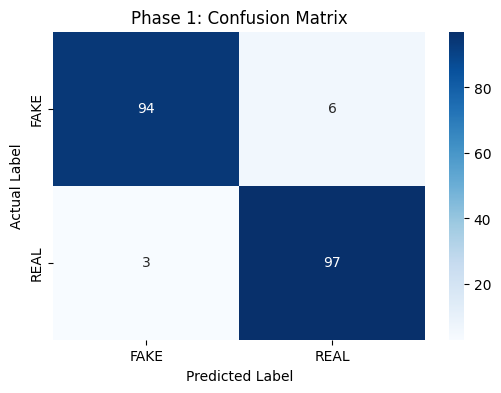

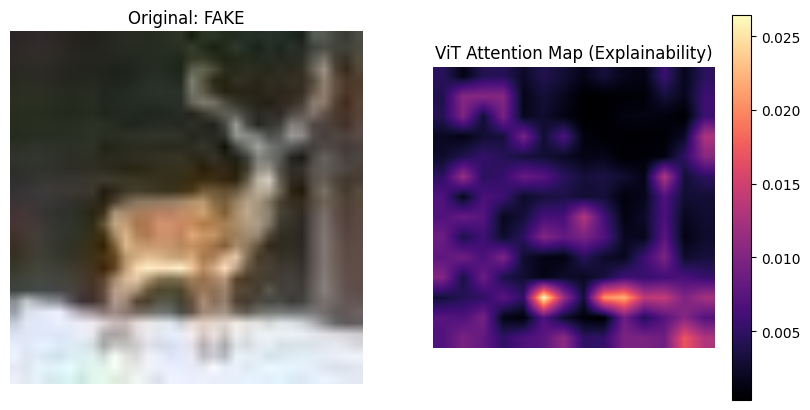

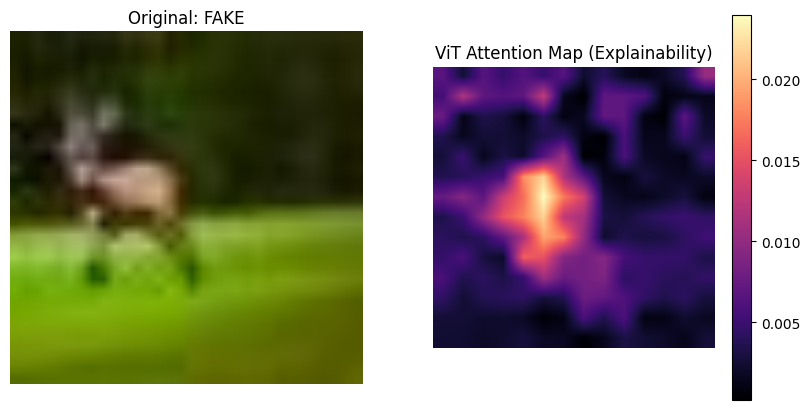

In [3]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from transformers import ViTImageProcessor, ViTForImageClassification
from sklearn.metrics import classification_report, confusion_matrix

# 1. DATASET DOWNLOAD
import kagglehub
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

# 2. SETUP & DATA LOADING
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

model_name = 'google/vit-base-patch16-224'
processor = ViTImageProcessor.from_pretrained(model_name)

# Transformations: Resize 32x32 to 224x224 and normalize [cite: 14]
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Load full datasets
full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
full_test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms)

# REDUCE DATASET SIZE: 1000 Total Train (500/class), 200 Total Test (100/class) [cite: 55]
def get_balanced_subset_indices(dataset, num_per_class=500):
    indices = []
    targets = np.array(dataset.targets)
    for class_idx in range(len(dataset.classes)):
        class_indices = np.where(targets == class_idx)[0]
        subset = np.random.choice(class_indices, num_per_class, replace=False)
        indices.extend(subset)
    return indices

train_indices = get_balanced_subset_indices(full_train_dataset, num_per_class=500)
test_indices = get_balanced_subset_indices(full_test_dataset, num_per_class=100)

train_dataset = Subset(full_train_dataset, train_indices)
test_dataset = Subset(full_test_dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. MODEL INITIALIZATION (Build)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True,
    output_attentions=True # Critical for Phase 1 Explainability
).to(device)

# 4. TRAINING LOOP
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)
criterion = torch.nn.CrossEntropyLoss()

model.train()
for epoch in range(1):
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc="Training Phase 1"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch 1 Loss: {running_loss/len(train_loader):.4f}")

# 5. FULL EVALUATIONS
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# A. Classification Report (Accuracy, Precision, Recall, F1)
print("\n--- PHASE 1 EVALUATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=['FAKE', 'REAL']))

# B. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.title('Phase 1: Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. VISUAL EXPLAINABILITY (Attention Maps)
def plot_attention_map(model, img_tensor, label, idx):
    model.eval()
    img_input = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_input)

    # Get last layer attentions [cite: 34]
    attentions = outputs.attentions[-1]
    # Average across heads for CLS token attention to patches
    avg_attn = torch.mean(attentions[0, :, 0, 1:], dim=0).reshape(14, 14).cpu().numpy()

    # Denormalize image for display
    img_display = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_display = (img_display * np.array(processor.image_std)) + np.array(processor.image_mean)
    img_display = np.clip(img_display, 0, 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(img_display)
    ax1.set_title(f"Original: {'REAL' if label==1 else 'FAKE'}")
    ax1.axis('off')

    im2 = ax2.imshow(avg_attn, cmap='magma', interpolation='bilinear')
    ax2.set_title("ViT Attention Map (Explainability)")
    plt.colorbar(im2, ax=ax2)
    ax2.axis('off')
    plt.show()

# Visualize explainability for a few samples [cite: 18, 34]
for i in range(2):
    sample_img, sample_label = test_dataset[i]
    plot_attention_map(model, sample_img, sample_label, i)